In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_california_housing
df = fetch_california_housing(as_frame=True).frame

# 타겟정의, 데이터 분할 
y = df['MedHouseVal']
X = df.drop('MedHouseVal', axis=1)

from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

## 선형모델을 위한 스케일링 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# --------------------------------------------------
# 모델 정의
# --------------------------------------------------

models = {

    # 1. Linear regression
    "Linear": LinearRegression(),

    # 2. Ridge
    # L2 = 10    ## 0.1, 1, 10, 100   (회귀계수 크기를 얼마나 줄일까?)
    "Ridge": Ridge(alpha=10),

    # 3. Lasso
    # L1 = 0.1    ## 0.0001, 0.001, 0.01, 0.1, 1  (어디서부터 회귀계수를 없앨까?)
    "Lasso": Lasso(alpha=0.1),

    # 4. Elastic Net
    # Alpha는 전체 규제의 강도, l1_ration는 L1 & L2 규제의 혼합 비율을 의미한다.
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),

    # 5. KNN 
    # k = 4   # 3,4,5,6,7     (최근접 k개의 평균을 낸다.)
    "KNN": KNeighborsRegressor(n_neighbors=4),

    # 1. Decision Tree 
    "DecisionTree": DecisionTreeRegressor(random_state=42),

    # 2. Random forest
    "RandomForest": RandomForestRegressor(random_state=42),

    # 3. Gradient Boosting 
    "GradientBoosting": GradientBoostingRegressor(random_state=42),

    # 4. Gradient Boosting with tunning 
    "GradientBoosting_Tuned": GradientBoostingRegressor(
        random_state=42, 
        learning_rate = 0.05,     # 학습율 0.1 -> 0.05 (보다 더 자세히 학습)  
        n_estimators = 500,       # 반복횟수 100 -> 500 
        max_depth = 3,            # 기본값 사용 
        subsample = 0.8           # 1.0 -> 0.8 (과적합 방지위해 각 트리 학습시 데이터의 80%만 사용)
    ),

    # 1. LightGBM 
    "LightGBM": LGBMRegressor(random_state=42, verbosity=-1),

    # 2. XGBoost
    "XGBoost": XGBRegressor(random_state=42)

}

# --------------------------------------------------
# 모델 학습 및 평가
# --------------------------------------------------

results = []

for name, model in models.items():

    # 선형계열 & KNN 은 스케일링 데이터 사용
    if name in ["Linear", "Ridge", "Lasso", "ElasticNet", "KNN"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_valid_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_valid)

    rmse = root_mean_squared_error(y_valid, pred)
    r2 = r2_score(y_valid, pred)

    results.append([name, rmse, r2])

# --------------------------------------------------
# 성능 비교 DataFrame 생성
# --------------------------------------------------

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

display(results_df)

,Model,RMSE,R2
0,LightGBM,0.463517,0.836045
1,XGBoost,0.471794,0.830137
2,GradientBoosting_Tuned,0.501430,0.808127
3,RandomForest,0.505694,0.804850
4,GradientBoosting,0.542215,0.775645
5,KNN,0.668850,0.658610
6,DecisionTree,0.706900,0.618663
7,Ridge,0.745342,0.576060
8,Linear,0.745581,0.575788
9,ElasticNet,0.797406,0.514765


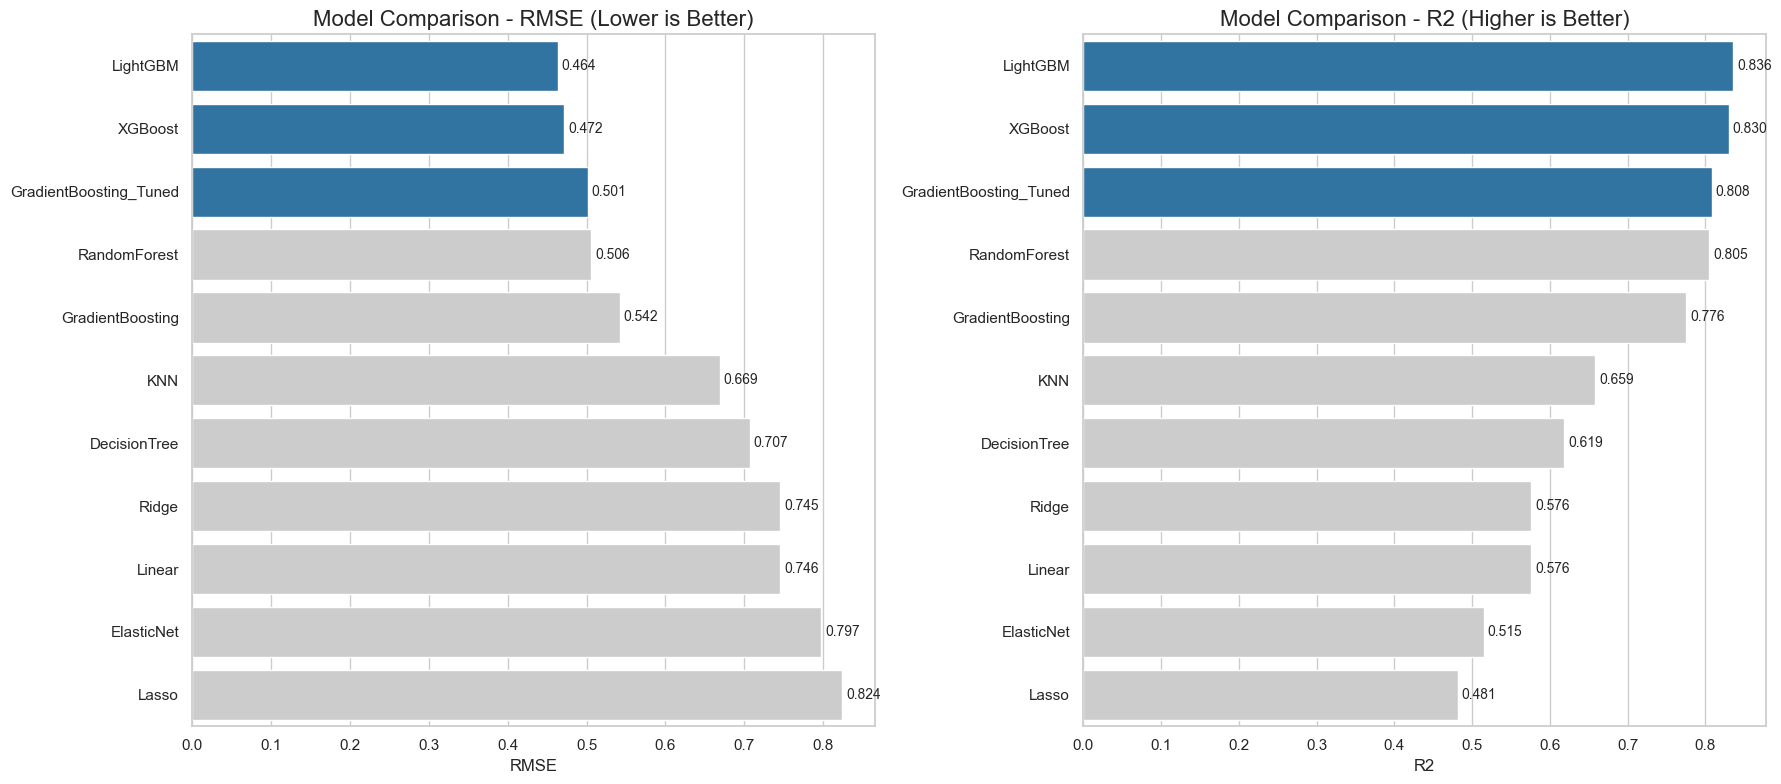

In [ ]:
# 시각화 
rmse_sorted = results_df.sort_values("RMSE", ascending=True)  # 낮은 RMSE 위로
r2_sorted = results_df.sort_values("R2", ascending=False)     # 높은 R2 위로

# 색상 설정: 상위 3개 모델 강조
palette_rmse = ['#1f77b4' if i<3 else '#cccccc' for i in range(len(rmse_sorted))]
palette_r2 = ['#1f77b4' if i<3 else '#cccccc' for i in range(len(r2_sorted))]

fig, axes = plt.subplots(1,2, figsize=(18,8))

# -----------------------
# RMSE
# -----------------------
sns.barplot(data=rmse_sorted, y='Model', x='RMSE', ax=axes[0], palette=palette_rmse)
axes[0].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=16)
axes[0].set_xlabel('RMSE', fontsize=12)
axes[0].set_ylabel('')
# 값 표시
for i, v in enumerate(rmse_sorted["RMSE"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)

# -----------------------
# R2
# -----------------------
sns.barplot(data=r2_sorted, y='Model', x='R2', ax=axes[1], palette=palette_r2)
axes[1].set_title('Model Comparison - R2 (Higher is Better)', fontsize=16)
axes[1].set_xlabel('R2', fontsize=12)
axes[1].set_ylabel('')
# 값 표시
for i, v in enumerate(r2_sorted["R2"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.show()